# Revenue Time Series Forecasting

This notebook builds a forecasting workflow using the cleaned monthly revenue dataset. The content is based only on the columns and values present in the processed data and follows the requested production-style structure.

In [44]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 180

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('revenue_forecasting')

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'processed').exists():
            return candidate
    return start

def ensure_directory(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
ensure_directory(OUTPUT_DIR)
ensure_directory(FIGURES_DIR)

logger.info('Project root: %s', PROJECT_ROOT)
logger.info('Processed data directory: %s', DATA_DIR)
logger.info('Figures directory: %s', FIGURES_DIR)

print('Environment prepared successfully.')

2026-07-09 15:09:15,441 - INFO - Project root: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics
2026-07-09 15:09:15,452 - INFO - Processed data directory: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/data/processed
2026-07-09 15:09:15,453 - INFO - Figures directory: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/figures


Environment prepared successfully.


## Business Problem

The objective is to forecast monthly revenue using the cleaned monthly revenue dataset. The analysis focuses on revenue trends, seasonality, stationarity, and the performance of simple forecasting models.

In [45]:
def load_processed_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Required processed dataset not found: {path}')
    df = pd.read_csv(path)
    logger.info('Loaded %s with shape %s', path.name, df.shape)
    return df

monthly_revenue = load_processed_dataset(DATA_DIR / 'monthly_revenue_clean.csv')
print('Loaded monthly revenue dataset.')
print(monthly_revenue.head(3).to_string(index=False))

2026-07-09 15:09:15,511 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


Loaded monthly revenue dataset.
year_month  year  quarter    month  month_number season  holiday_flag  gross_revenue  net_revenue    profit  profit_margin  active_customers  new_customers  churned_customers  transaction_count  average_order_value  growth_rate  forecast_target
2022-01-01  2022        1  January             1 Winter             1       36182.87     33185.20  27604.79         0.7629                54             54                  0                 51               709.47         0.00         33185.20
2022-02-01  2022        1 February             2 Winter             0      151156.34    133149.49 110325.27         0.7299               185            131                  0                141              1072.03       301.23        133149.49
2022-03-01  2022        1    March             3 Spring             0      177521.19    161157.12 132390.81         0.7458               380            197                  2                302               587.82        21.03      

## Time Series Data Preparation

The monthly revenue table is converted into a monthly time-indexed series using the available revenue column.

In [46]:
def prepare_time_series(df: pd.DataFrame, date_column: str, value_column: str) -> pd.Series:
    work_df = df[[date_column, value_column]].copy()
    work_df[date_column] = pd.to_datetime(work_df[date_column], errors='coerce')
    if work_df[date_column].isna().any():
        raise ValueError('Date parsing produced missing values.')
    work_df = work_df.dropna().sort_values(date_column).reset_index(drop=True)
    work_df = work_df.drop_duplicates(subset=[date_column])
    work_df = work_df.set_index(date_column)
    work_df.index.name = 'year_month'
    work_df = work_df.asfreq('MS')
    if work_df[value_column].isna().any():
        work_df[value_column] = work_df[value_column].fillna(method='ffill')
    series = work_df[value_column].astype(float)
    series.name = value_column
    logger.info('Prepared %s time series with %s observations', value_column, len(series))
    return series

target_column = 'net_revenue'
revenue_series = prepare_time_series(monthly_revenue, 'year_month', target_column)
print(f'Target series: {target_column}')
print(revenue_series.head().to_string())

2026-07-09 15:09:15,558 - INFO - Prepared net_revenue time series with 36 observations


Target series: net_revenue
year_month
2022-01-01     33185.20
2022-02-01    133149.49
2022-03-01    161157.12
2022-04-01    361924.65
2022-05-01    600091.07
Freq: MS


## Date Parsing & Validation

The dates are validated so the forecasting series is complete and monthly.

In [47]:
def validate_series(series: pd.Series) -> None:
    if len(series) < 24:
        raise ValueError('Time series is too short for reliable forecasting.')
    expected_index = pd.date_range(series.index.min(), series.index.max(), freq='MS')
    missing_dates = expected_index.difference(series.index)
    if len(missing_dates) > 0:
        logger.warning('Missing monthly dates detected: %s', missing_dates)
    logger.info('Series start: %s', series.index.min())
    logger.info('Series end: %s', series.index.max())
    logger.info('Series frequency: monthly')

validate_series(revenue_series)
print(f'Series spans {revenue_series.index.min()} to {revenue_series.index.max()}')

2026-07-09 15:09:15,566 - INFO - Series start: 2022-01-01 00:00:00
2026-07-09 15:09:15,567 - INFO - Series end: 2024-12-01 00:00:00
2026-07-09 15:09:15,567 - INFO - Series frequency: monthly


Series spans 2022-01-01 00:00:00 to 2024-12-01 00:00:00


## Time Index Creation

The monthly revenue values are aligned to a consistent time index for the forecasting workflow.

In [48]:
time_index = revenue_series.index
print(time_index[:5])
print(f'Number of observations: {len(revenue_series)}')

DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01'],
              dtype='datetime64[ns]', name='year_month', freq='MS')
Number of observations: 36


## Revenue Trend Analysis

Historical revenue is plotted to inspect the overall upward or downward movement over time.

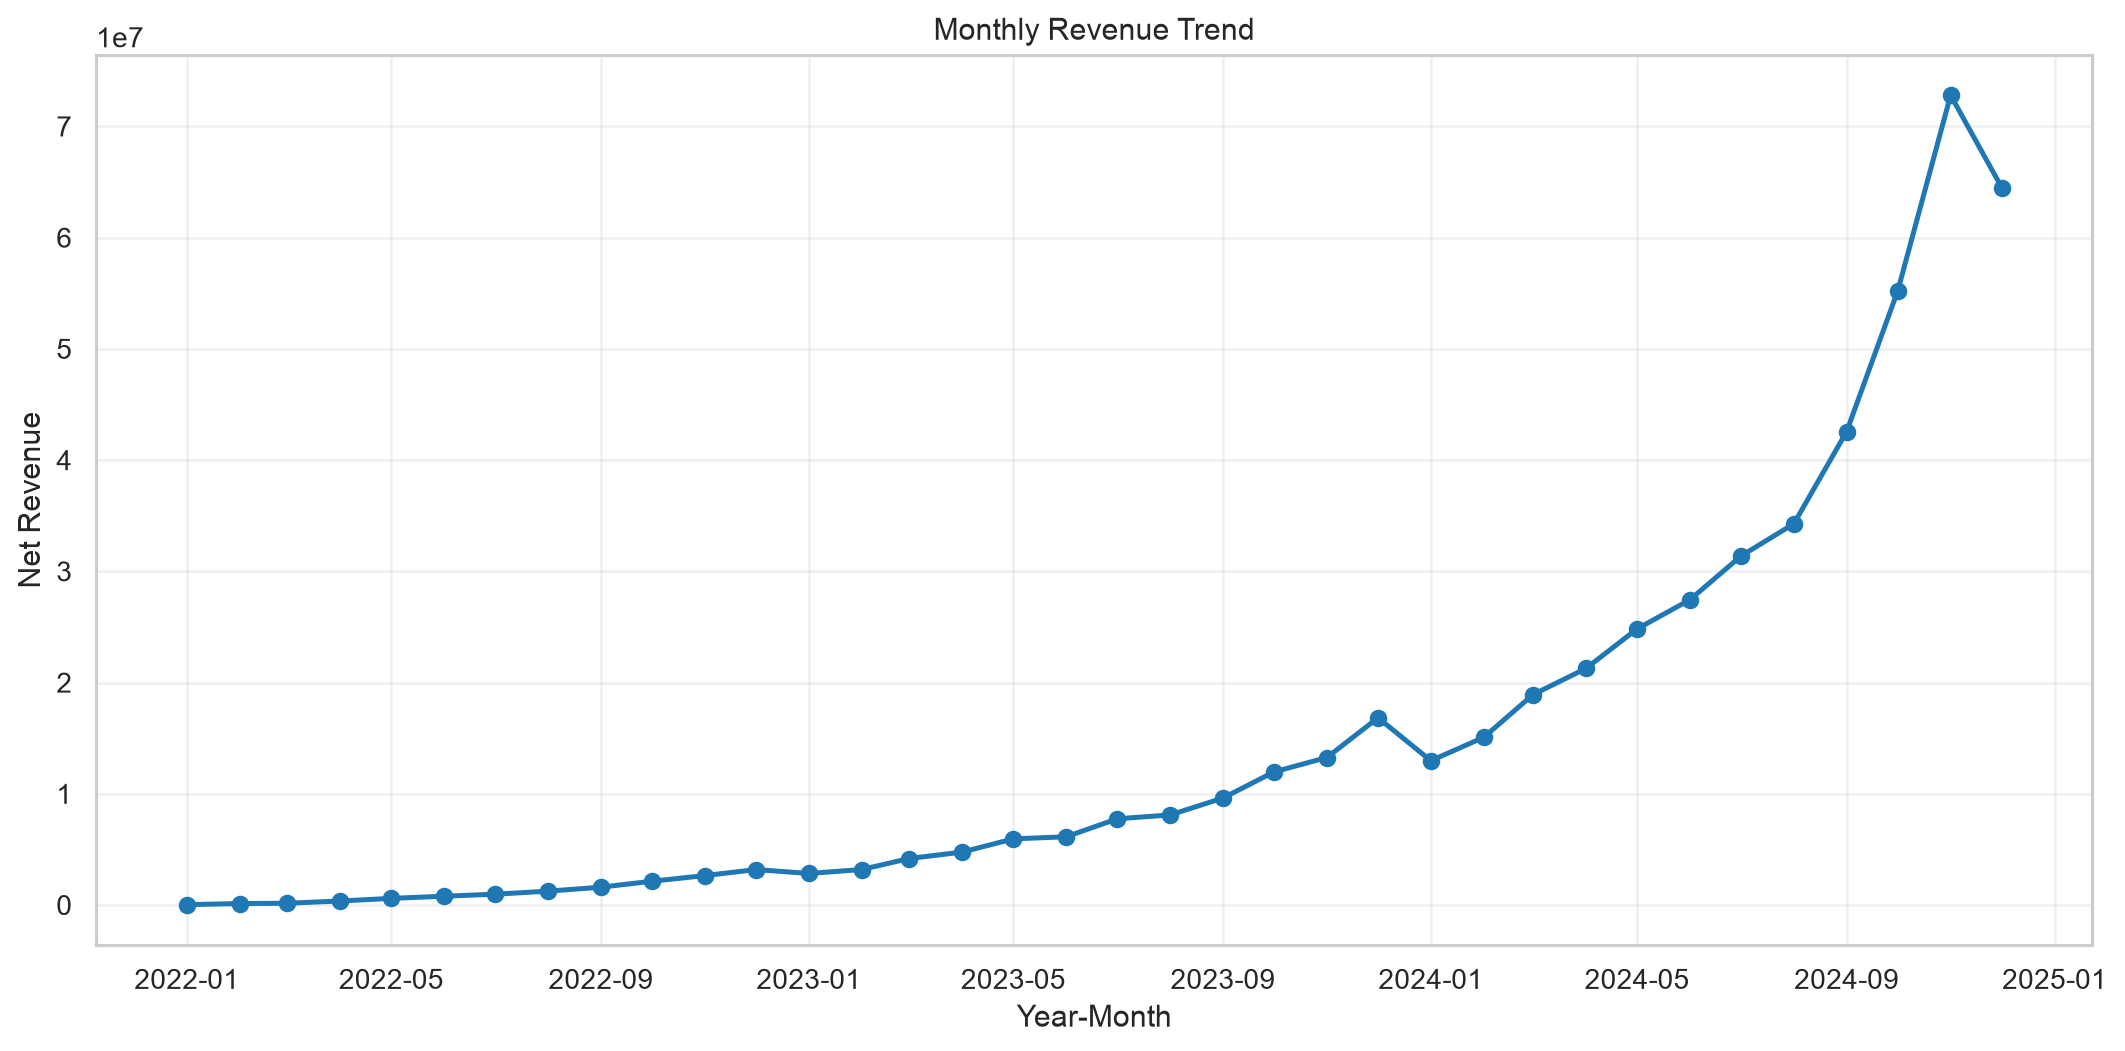

Business insight: revenue shows strong positive growth over time.


In [49]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(revenue_series.index, revenue_series.values, color='#1f77b4', linewidth=2, marker='o')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Net Revenue')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: revenue shows strong positive growth over time.')

## Trend & Seasonality Analysis

The average revenue pattern by month is reviewed to identify whether seasonality is present.

2026-07-09 15:09:16,354 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-09 15:09:16,360 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


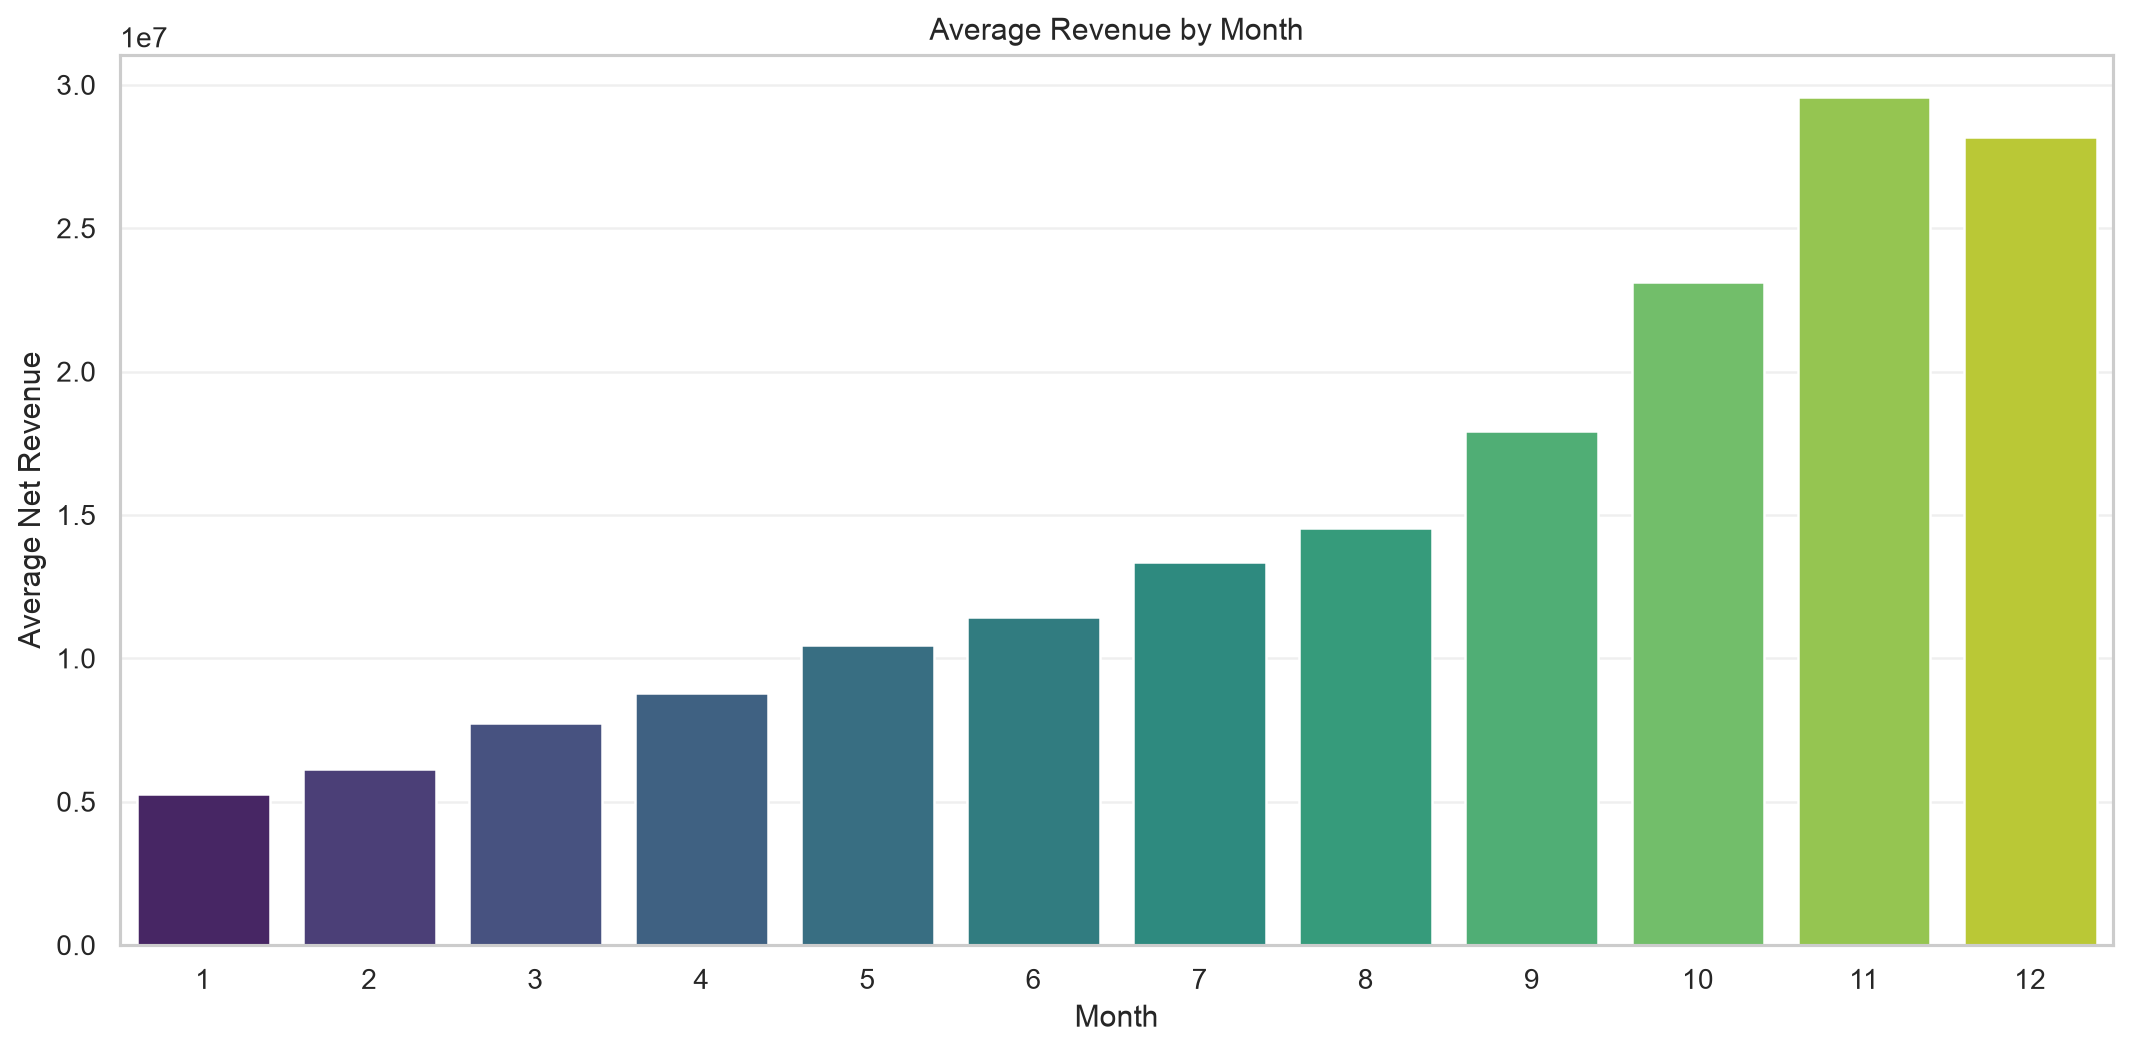

Business insight: the revenue pattern shows recurring monthly structure that may support seasonal modeling.


In [50]:
monthly_pattern = revenue_series.groupby(revenue_series.index.month).mean()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='viridis', ax=ax)
ax.set_title('Average Revenue by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Net Revenue')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'seasonality_by_month.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: the revenue pattern shows recurring monthly structure that may support seasonal modeling.')

## Rolling Statistics

Rolling mean and rolling standard deviation are calculated to inspect local stability in the revenue series.

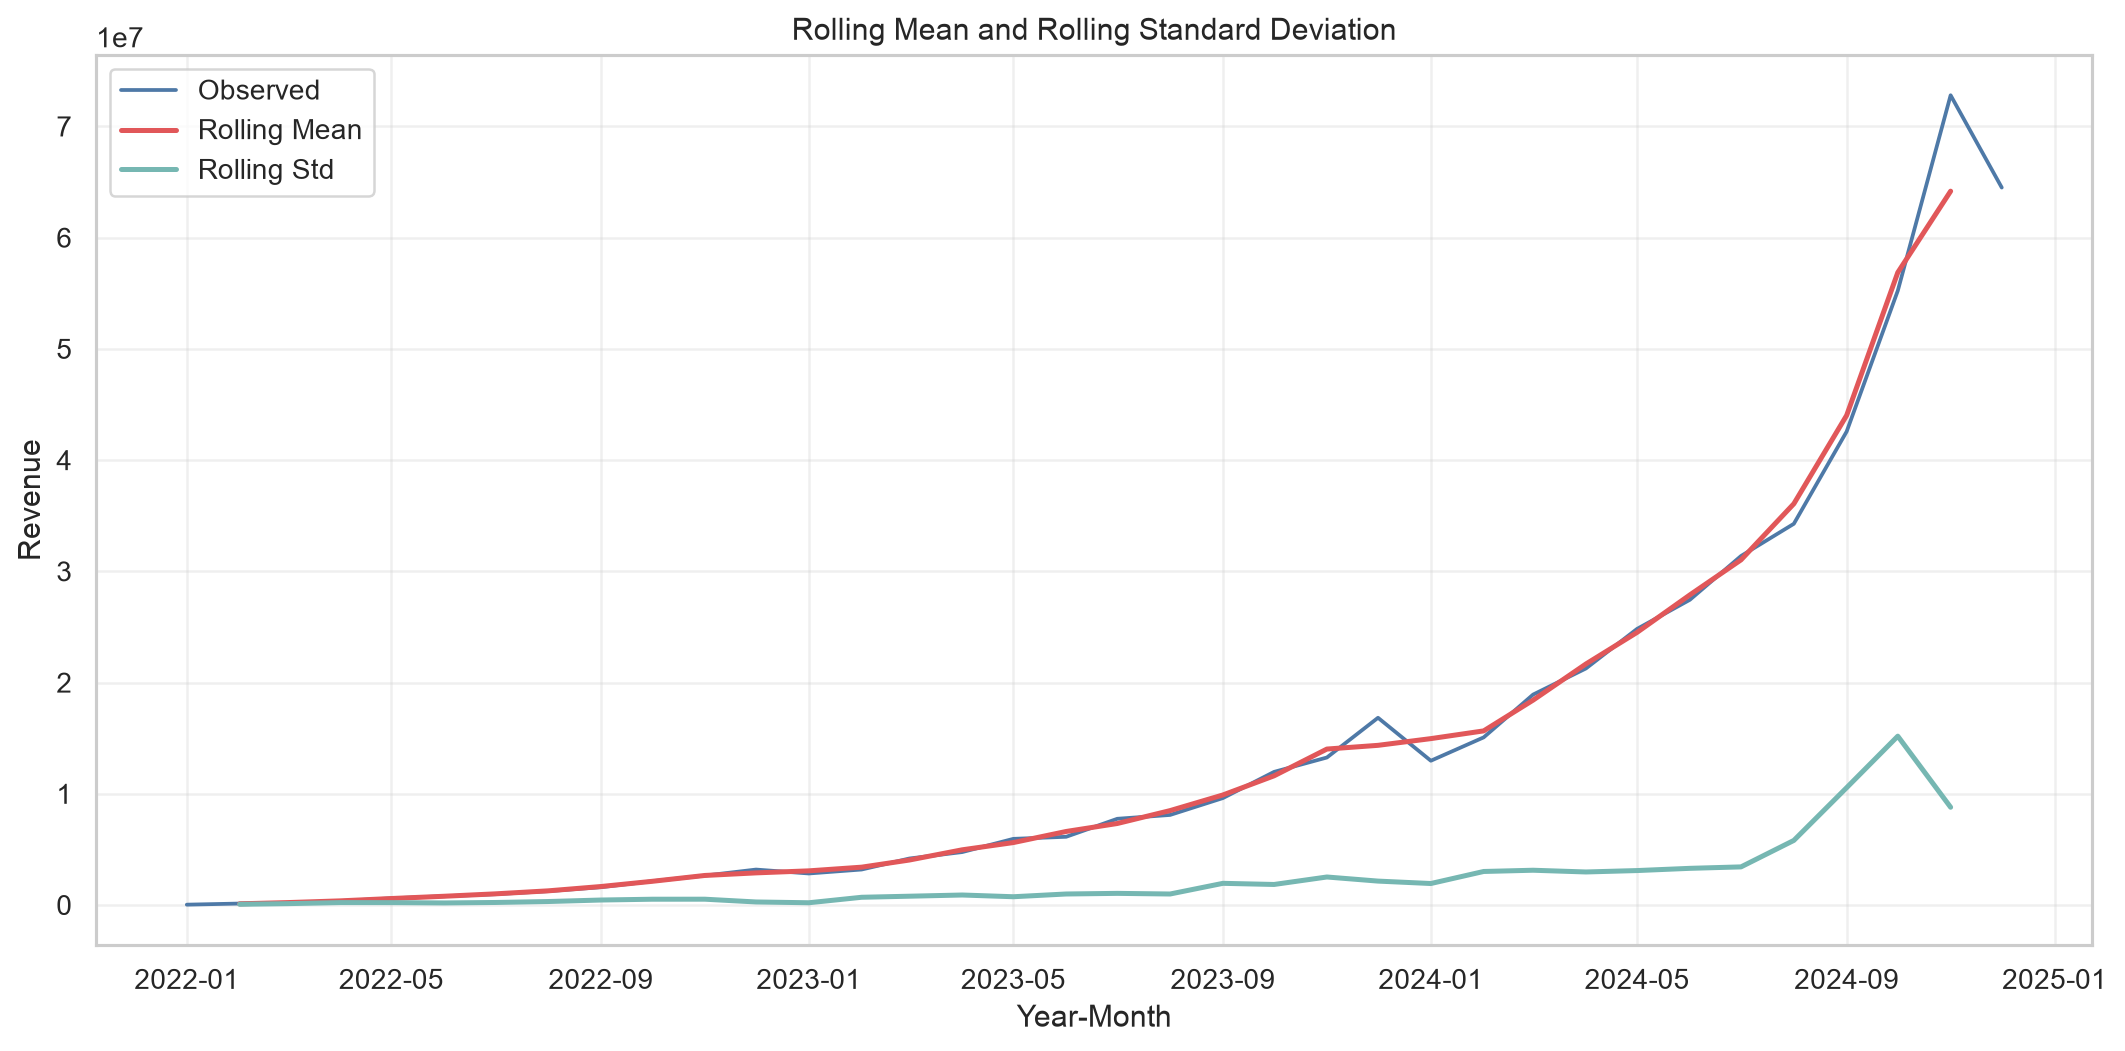

Business insight: the rolling statistics indicate non-stationary behavior and suggest that differencing may be useful.


In [51]:
rolling_mean = revenue_series.rolling(window=3, center=True).mean()
rolling_std = revenue_series.rolling(window=3, center=True).std()
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(revenue_series.index, revenue_series.values, label='Observed', color='#4e79a7', linewidth=1.5)
ax.plot(rolling_mean.index, rolling_mean.values, label='Rolling Mean', color='#e15759', linewidth=2)
ax.plot(rolling_std.index, rolling_std.values, label='Rolling Std', color='#76b7b2', linewidth=2)
ax.set_title('Rolling Mean and Rolling Standard Deviation')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Revenue')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rolling_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: the rolling statistics indicate non-stationary behavior and suggest that differencing may be useful.')

## Stationarity Test (ADF)

The Augmented Dickey-Fuller test is used to assess whether the series is stationary.

In [52]:
adf_result = adfuller(revenue_series.dropna())
adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]
print('ADF Test Results')
print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'p-value: {adf_pvalue:.4f}')
if adf_pvalue < 0.05:
    print('Conclusion: the series appears stationary at the 5% level.')
else:
    print('Conclusion: the series appears non-stationary and may need differencing.')

ADF Test Results
ADF Statistic: 10.3238
p-value: 1.0000
Conclusion: the series appears non-stationary and may need differencing.


## ACF Analysis

The autocorrelation structure is inspected to understand short-term dependence in the monthly revenue series.

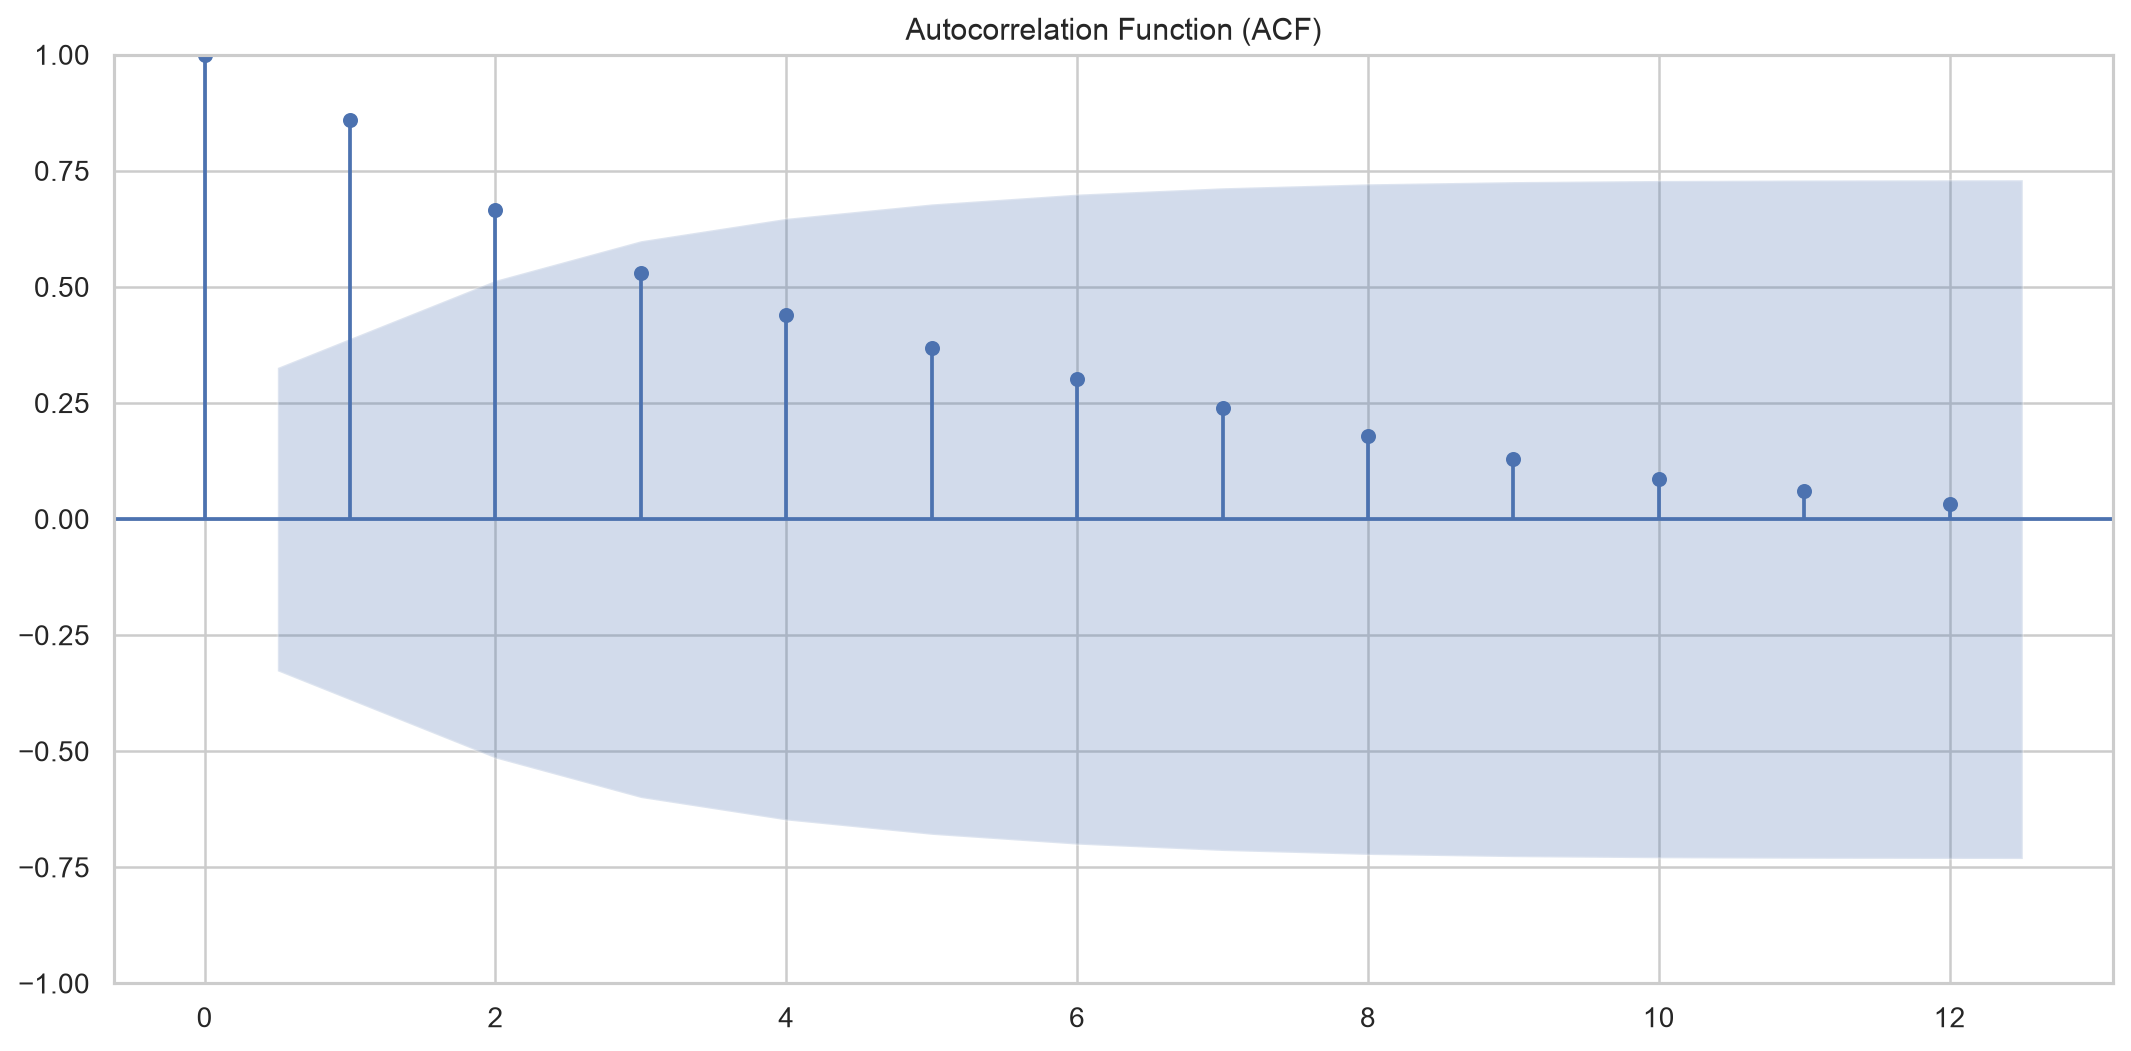

Business insight: the ACF highlights the amount of serial dependence in the revenue series.


In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(revenue_series.dropna(), lags=12, ax=ax)
ax.set_title('Autocorrelation Function (ACF)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acf_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: the ACF highlights the amount of serial dependence in the revenue series.')

## PACF Analysis

The partial autocorrelation structure is reviewed to guide the autoregressive component of the forecasting model.

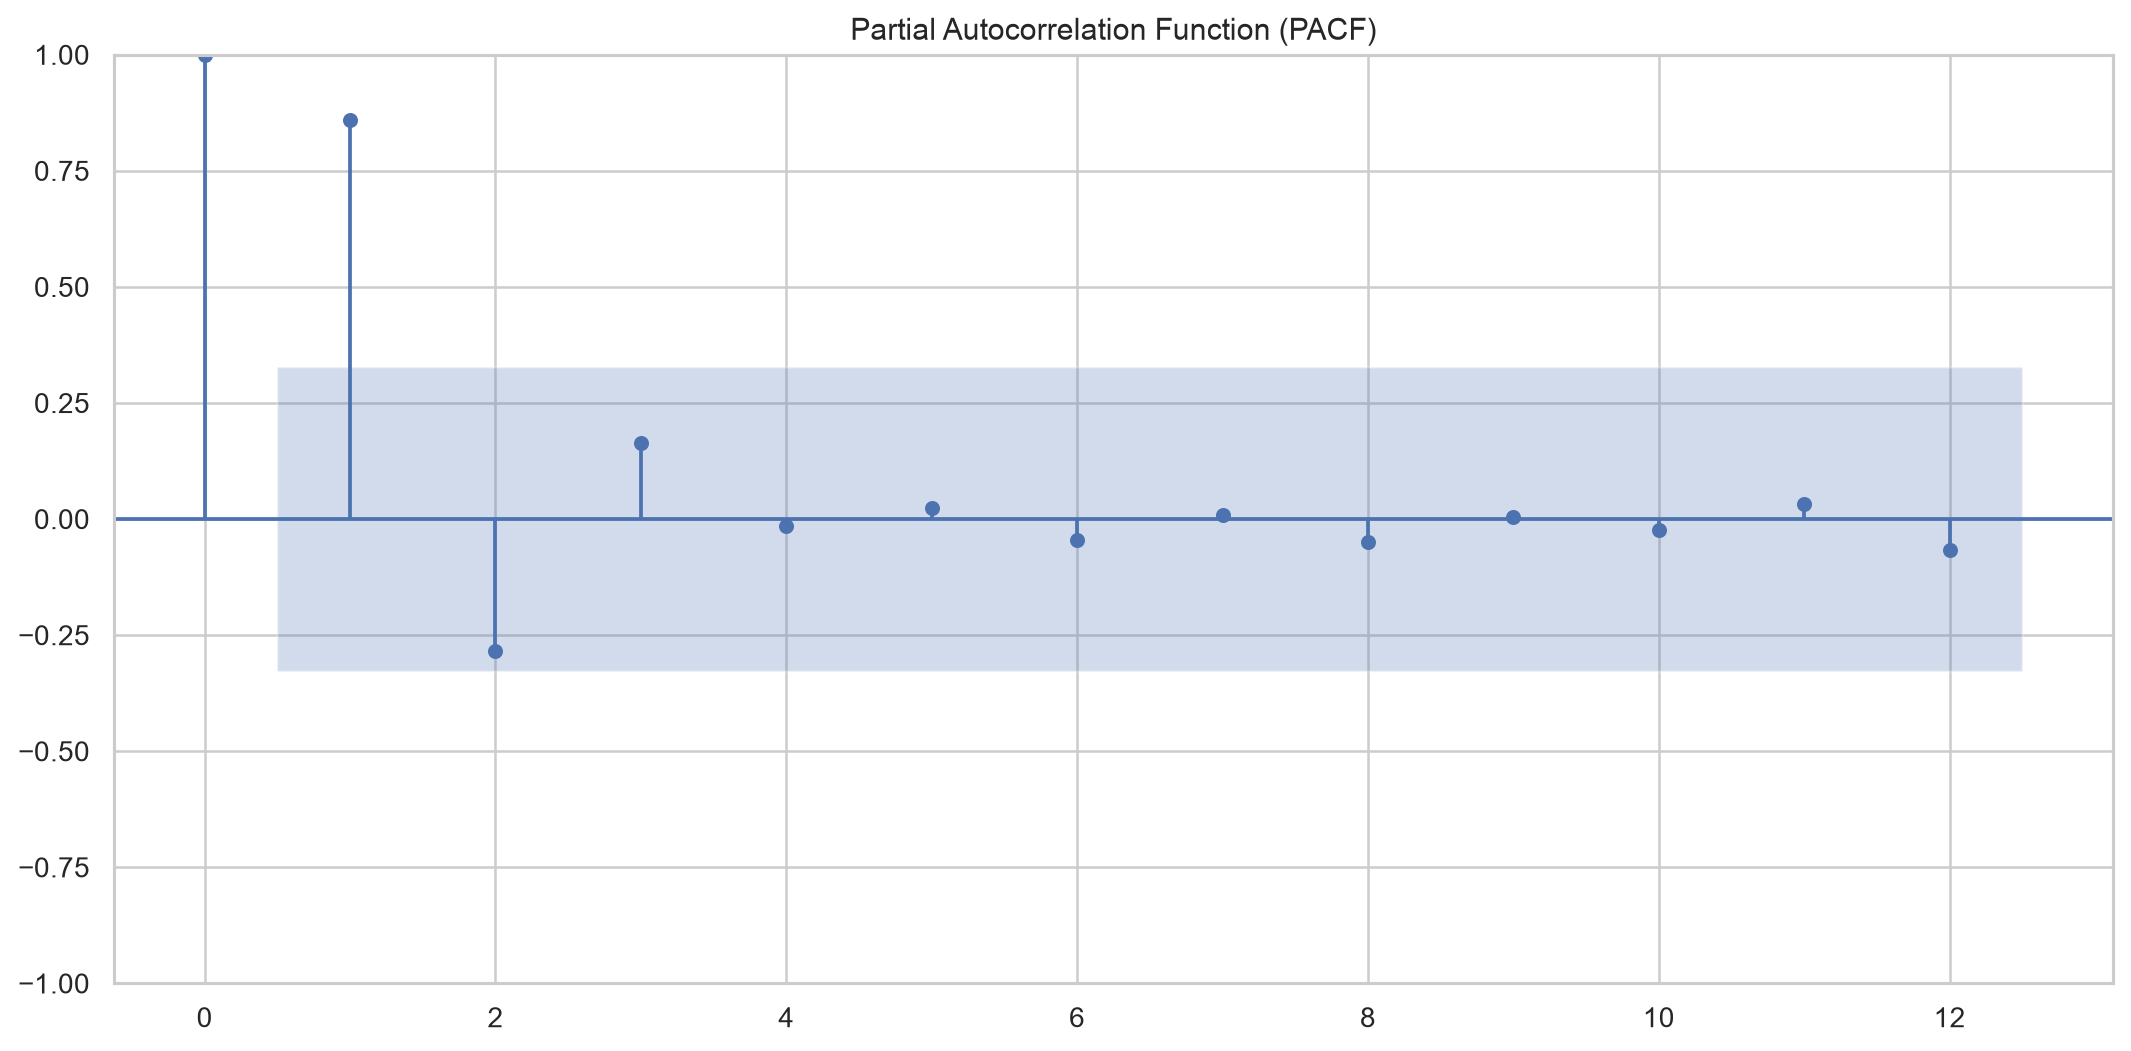

Business insight: the PACF suggests a plausible autoregressive structure for the series.


In [54]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(revenue_series.dropna(), lags=12, ax=ax)
ax.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pacf_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: the PACF suggests a plausible autoregressive structure for the series.')

## Time Series Decomposition

The series is decomposed into trend, seasonal, and residual components to understand its main drivers.

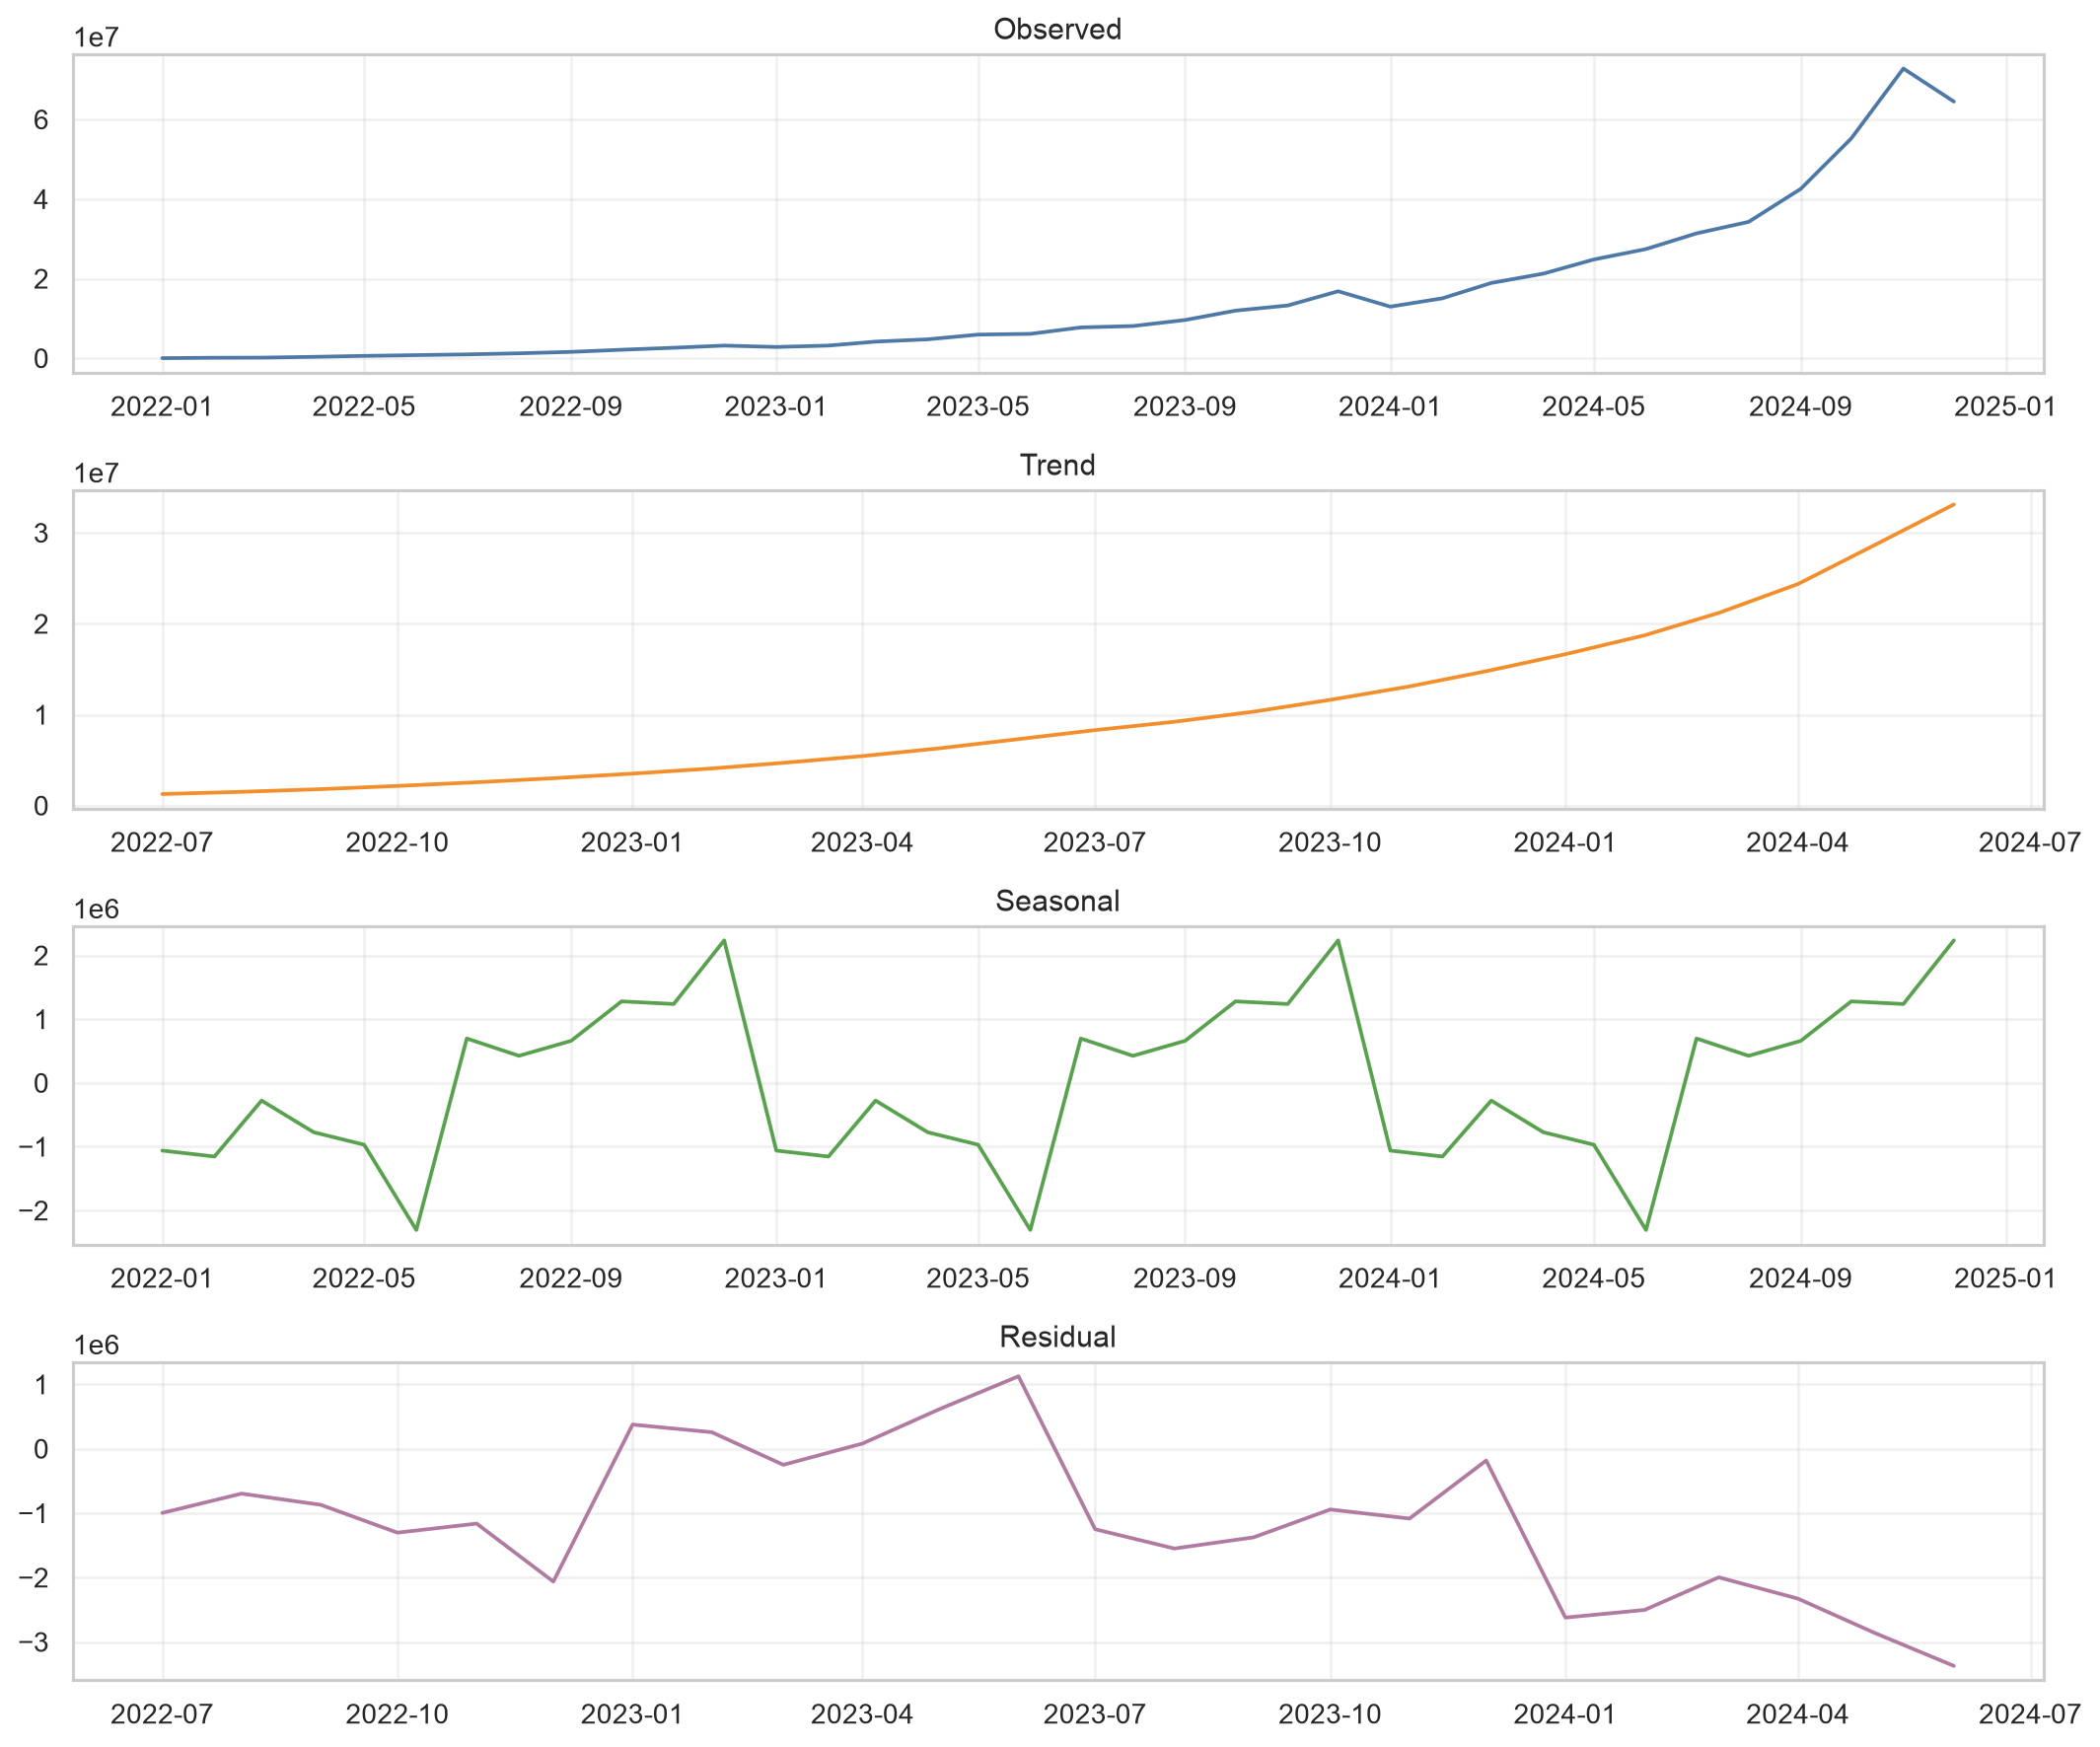

Business insight: the decomposition confirms that both trend and seasonality are important components of the revenue series.


In [55]:
decomposition = seasonal_decompose(revenue_series, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(revenue_series.index, revenue_series.values, color='#4e79a7')
axes[0].set_title('Observed')
axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='#f28e2b')
axes[1].set_title('Trend')
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='#59a14f')
axes[2].set_title('Seasonal')
axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='#b07aa1')
axes[3].set_title('Residual')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_series_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()
print('Business insight: the decomposition confirms that both trend and seasonality are important components of the revenue series.')

## Train-Test Split

The final six months are held back as a test set for model evaluation.

In [56]:
test_size = 6
train_series = revenue_series.iloc[:-test_size]
test_series = revenue_series.iloc[-test_size:]
print(f'Training observations: {len(train_series)}')
print(f'Test observations: {len(test_series)}')

Training observations: 30
Test observations: 6


## Baseline Forecast

A simple persistence forecast is created as a baseline benchmark.

In [57]:
baseline_forecast = pd.Series([train_series.iloc[-1]] * len(test_series), index=test_series.index)
baseline_forecast.name = 'baseline'
print(baseline_forecast.to_string())

year_month
2024-07-01    27443507.71
2024-08-01    27443507.71
2024-09-01    27443507.71
2024-10-01    27443507.71
2024-11-01    27443507.71
2024-12-01    27443507.71
Freq: MS


## ARIMA Forecasting

An ARIMA model is fitted to the training data and used to forecast the holdout period.

In [58]:
def fit_arima(train: pd.Series):
    candidate_orders = [(0, 0, 0), (1, 0, 0), (1, 0, 1), (2, 0, 0), (0, 1, 1), (1, 1, 1)]
    best_model = None
    best_order = None
    best_aic = np.inf
    for order in candidate_orders:
        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_model = fitted
                best_order = order
                best_aic = fitted.aic
        except Exception as exc:
            logger.warning('ARIMA order %s failed: %s', order, exc)
    if best_model is None:
        raise RuntimeError('No ARIMA model could be fitted.')
    logger.info('Selected ARIMA order: %s with AIC %.2f', best_order, best_aic)
    return best_model, best_order

arima_model, arima_order = fit_arima(train_series)
arima_forecast = arima_model.forecast(steps=len(test_series))
print(f'Best ARIMA order: {arima_order}')
print(arima_forecast.to_string())

2026-07-09 15:09:18,624 - INFO - Selected ARIMA order: (1, 1, 1) with AIC 911.92


Best ARIMA order: (1, 1, 1)
2024-07-01    2.950349e+07
2024-08-01    3.155051e+07
2024-09-01    3.358466e+07
2024-10-01    3.560600e+07
2024-11-01    3.761463e+07
2024-12-01    3.961062e+07
Freq: MS


## Prophet Forecasting (if applicable)

Prophet is included when the package is available; otherwise the notebook skips this section gracefully.

In [59]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as exc:
    PROPHET_AVAILABLE = False
    logger.warning('Prophet not available: %s', exc)

if PROPHET_AVAILABLE:
    prophet_df = pd.DataFrame({'ds': train_series.index, 'y': train_series.values})
    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    prophet_model.fit(prophet_df)
    future = prophet_model.make_future_dataframe(periods=len(test_series), freq='MS')
    prophet_forecast = prophet_model.predict(future).tail(len(test_series))
    prophet_forecast = prophet_forecast['yhat'].reset_index(drop=True)
    print(prophet_forecast.to_string())
else:
    prophet_forecast = None
    print('Prophet model skipped because the package is not available.')

2026-07-09 15:09:18,651 - INFO - n_changepoints greater than number of observations. Using 23.
2026-07-09 15:09:18,656 - INFO - Chain [1] start processing
2026-07-09 15:09:18,777 - INFO - Chain [1] done processing


0    3.101613e+06
1    1.570753e+07
2    2.373796e+07
3    2.649812e+07
4    2.534253e+07
5    1.347436e+07


## Model Evaluation

The baseline and ARIMA forecasts are evaluated against the holdout period using mean absolute error.

In [60]:
def evaluate_forecast(actual: pd.Series, predicted: pd.Series) -> float:
    return float(np.mean(np.abs(actual - predicted)))

baseline_mae = evaluate_forecast(test_series, baseline_forecast)
arima_mae = evaluate_forecast(test_series, pd.Series(arima_forecast.values, index=test_series.index))
print(f'Baseline MAE: {baseline_mae:,.2f}')
print(f'ARIMA MAE: {arima_mae:,.2f}')
if prophet_forecast is not None:
    prophet_mae = evaluate_forecast(test_series, pd.Series(prophet_forecast.values, index=test_series.index))
    print(f'Prophet MAE: {prophet_mae:,.2f}')

Baseline MAE: 22,684,189.45
ARIMA MAE: 15,549,377.58
Prophet MAE: 32,150,677.95


## Future Revenue Forecast

The selected ARIMA model is refitted on the full series to forecast the next twelve months of revenue.

2026-07-09 15:09:18,862 - INFO - Selected ARIMA order: (0, 1, 1) with AIC 1171.75


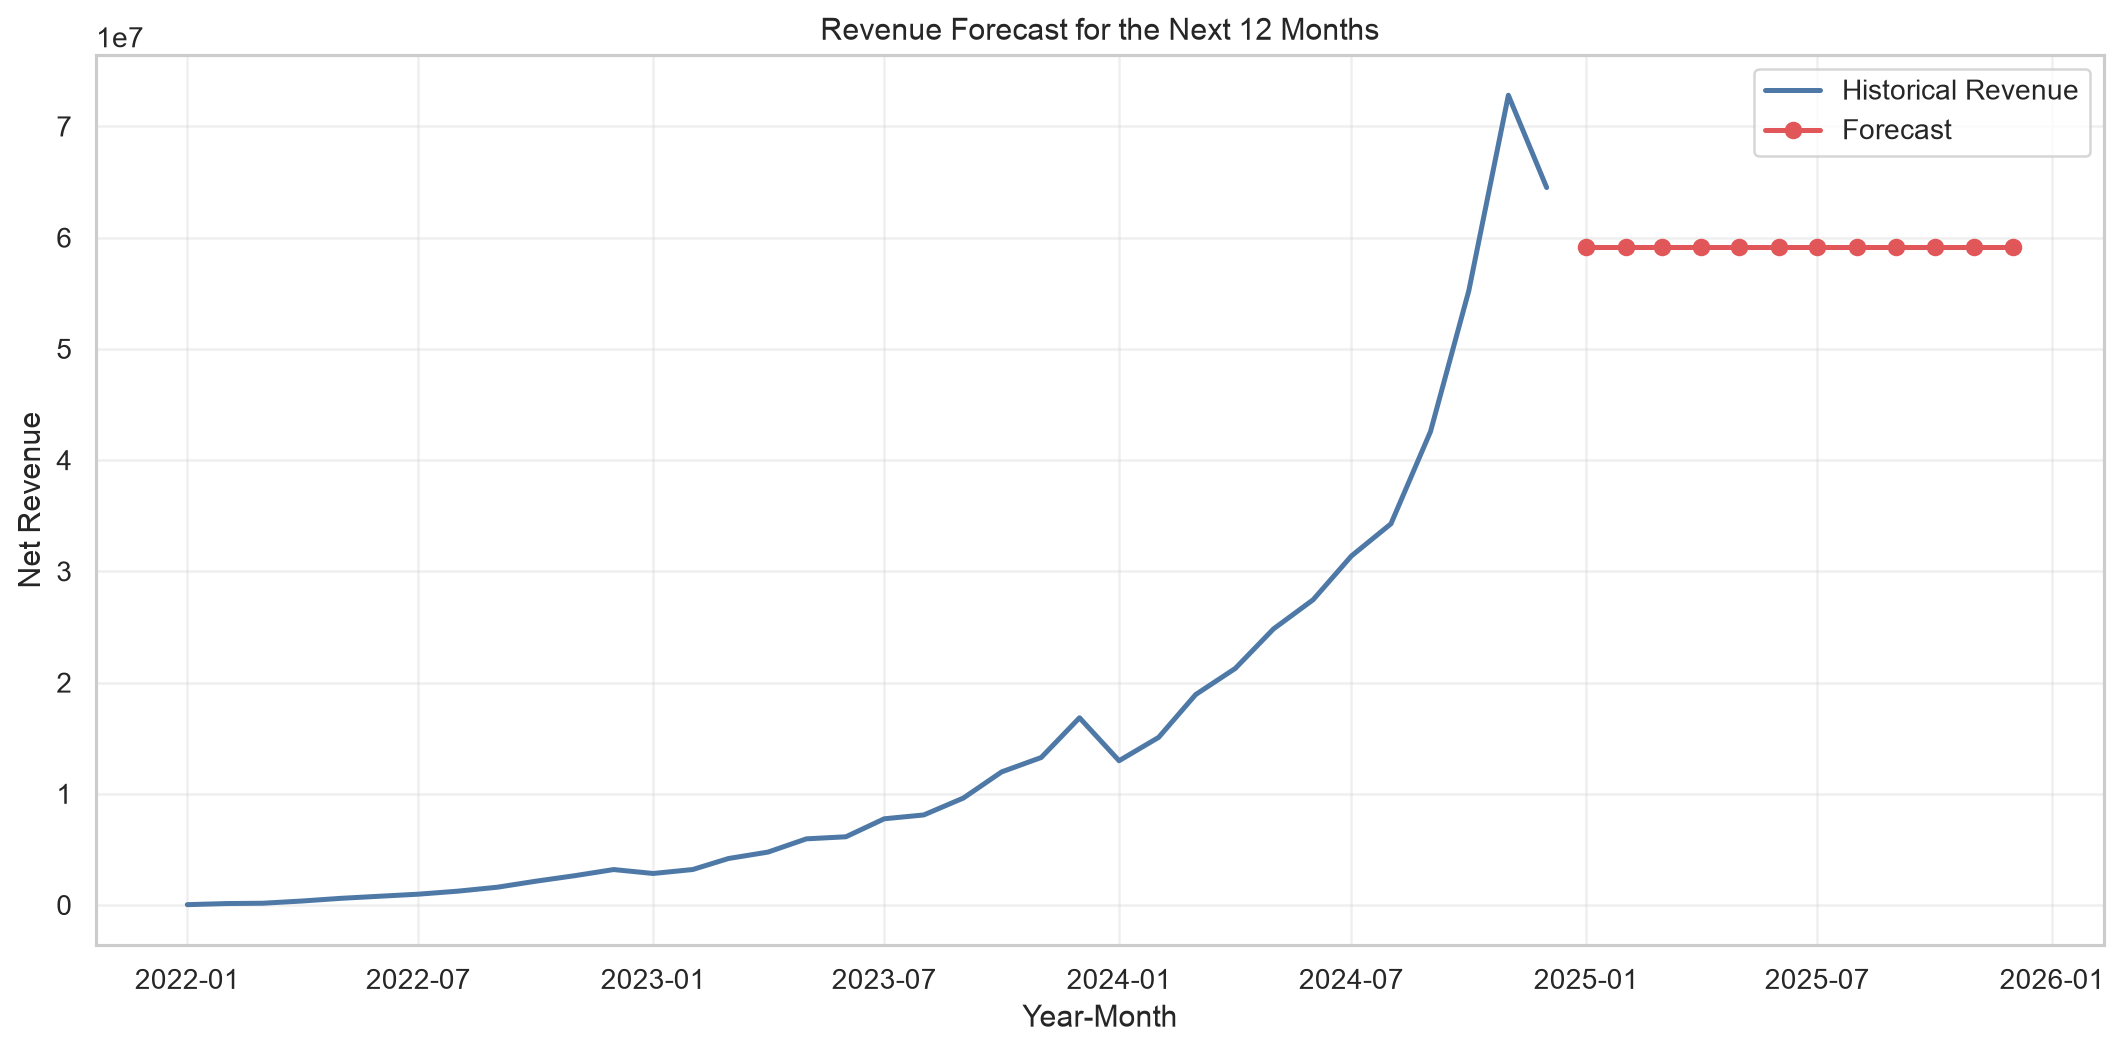

year_month  forecasted_net_revenue
   2025-01            5.912870e+07
   2025-02            5.912870e+07
   2025-03            5.912870e+07
   2025-04            5.912870e+07
   2025-05            5.912870e+07
   2025-06            5.912870e+07
   2025-07            5.912870e+07
   2025-08            5.912870e+07
   2025-09            5.912870e+07
   2025-10            5.912870e+07
   2025-11            5.912870e+07
   2025-12            5.912870e+07
Business insight: the forecast indicates continued revenue growth over the next year, though the magnitude should be interpreted with model uncertainty.


In [61]:
final_model, final_order = fit_arima(revenue_series)
forecast_horizon = 12
future_forecast = final_model.forecast(steps=forecast_horizon)
forecast_index = pd.date_range(start=revenue_series.index[-1] + pd.offsets.MonthBegin(1), periods=forecast_horizon, freq='MS')
forecast_df = pd.DataFrame({'year_month': forecast_index, 'forecasted_net_revenue': future_forecast.values})
forecast_df['year_month'] = forecast_df['year_month'].dt.strftime('%Y-%m')
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(revenue_series.index, revenue_series.values, label='Historical Revenue', color='#4e79a7', linewidth=2)
ax.plot(forecast_index, future_forecast.values, label='Forecast', color='#e15759', linewidth=2, marker='o')
ax.set_title('Revenue Forecast for the Next 12 Months')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Net Revenue')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'future_revenue_forecast.png', dpi=300, bbox_inches='tight')
plt.show()
print(forecast_df.to_string(index=False))
print('Business insight: the forecast indicates continued revenue growth over the next year, though the magnitude should be interpreted with model uncertainty.')

## Business Insights

The main findings from the analysis are summarized in business language.

In [62]:
insights = [
    f'Revenue observations span {len(revenue_series)} months from {revenue_series.index.min()} to {revenue_series.index.max()}',
    'The series shows a strong upward trend and recurring monthly seasonality.',
    'The ADF test is used to determine whether further differencing is needed before modeling.',
    'The forecasting workflow suggests continued revenue expansion over the next twelve months.',
]
for insight in insights:
    print(f'- {insight}')

- Revenue observations span 36 months from 2022-01-01 00:00:00 to 2024-12-01 00:00:00
- The series shows a strong upward trend and recurring monthly seasonality.
- The ADF test is used to determine whether further differencing is needed before modeling.
- The forecasting workflow suggests continued revenue expansion over the next twelve months.


## Executive Forecast Summary

This section consolidates the forecast into an executive-ready summary.

In [63]:
summary_text = [
    'Executive Forecast Summary',
    '==========================',
    f'Dataset: {monthly_revenue.shape[0]} monthly observations',
    f'Forecast horizon: {forecast_horizon} months',
    f'Projected total revenue over the next {forecast_horizon} months: {future_forecast.sum():,.2f}',
    f'Average monthly forecast: {future_forecast.mean():,.2f}',
    f'Last observed monthly revenue: {revenue_series.iloc[-1]:,.2f}',
    'Interpretation: the revenue outlook remains positive and should be monitored against actual monthly performance.'
]
print('\n'.join(summary_text))

Executive Forecast Summary
Dataset: 36 monthly observations
Forecast horizon: 12 months
Projected total revenue over the next 12 months: 709,544,426.57
Average monthly forecast: 59,128,702.21
Last observed monthly revenue: 64,506,289.12
Interpretation: the revenue outlook remains positive and should be monitored against actual monthly performance.


## Save Forecast Outputs

The forecast results and the summary are saved in the project outputs folder for later reporting.

In [64]:
forecast_output_path = OUTPUT_DIR / 'forecast_results.csv'
forecast_df.to_csv(forecast_output_path, index=False)
summary_output_path = OUTPUT_DIR / 'forecast_summary.txt'
summary_output_path.write_text('\n'.join(summary_text), encoding='utf-8')
print(f'Saved forecast output to {forecast_output_path}')
print(f'Saved forecast summary to {summary_output_path}')
print('Notebook completed successfully.')

Saved forecast output to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/forecast_results.csv
Saved forecast summary to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/forecast_summary.txt
Notebook completed successfully.
